# Rezonans stochastyczny w układzie bistabilnym

**Autor:** Tymoteusz Mastalerz 
**Przedmiot:** Modelowanie procesów stochastycznych
**Temat projektu:** Symulacja rezonansu stochastycznego w potencjale bistabilnym

## Cel projektu
Celem projektu jest numeryczne zbadanie zjawiska rezonansu stochastyczneo w układzie nieliniowym pobudzanym słabym sygnałem okresowym i szumem losowym. Badany układ opisuje ruch cząstki w potencjale bistabilnym.

W projekcie analizuję wpływ natężenia szumu \(D\) na odpowiedź układu. Głównym celem jest pokazanie, że dla pewnego pośredniego poziomu szumu odpowiedź układu na sygnał okresowy jest największa, co stanowi istotę rezonansu stochastycznego.

## Wprowadzenie teoretyczne
Rezonans stochastyczny to zjawisko polegające na maksymalizacji odpowiedzi układu nieliniowego na słabe pobudzenie okresowe dzięki dodaniu odpowiedniego poziomu szumu. Choć intuicyjnie szum kojarzy się z pogorszeniem jakości sygnału, w niektórych układach może on wspomagać przejścia między stanami i poprawiać wykrywalność sygnału.

Klasycznym przykładem jest cząstka poruszająca się w potencjale bistabilnym. Układ posiada dwa stabilne obszary odpowiadające dwóm studniom potencjału. Jeśli sygnał okresowy jest zbyt słaby, samodzielnie nie powoduje regularnych przejść między studniami. Dopiero odpowiednio dobranyc szum umożliwia synchornizację przejść z wymuszeniem okresowym.

## Model matematyczny

Rozważany układ opisuje równanie stochastyczne:

$\frac{dx}{dt} = -\frac{dV}{dx} + A \sin{\omega_s t} + \xi(t)$,  

gdzie:
- x(t) - położenie cząstki,
- V(x) - potencjał bistabilny,
- A \sin{\omega_s t} - słabe wymuszenie okresowe,
- \xi(t) - biały szum gaussowski o intensywności D.

Potencjał ma postać:

$V(x) = -\frac{1}{2}x^2 + \frac{1}{4}x^4$

Zatem siła deterministyczna wynika z pochodnej potencjału:

$- \frac{dV}{dt} = x - x^3$

Ostatecznie równanie ruchu przyjmuje postać:

$\frac{dx}{dt} = x - x^3 + A \sin{\omega_s t} + \xi(t)$

Dla białego szumu gaussowskiego zachodzi zależność:

$\langle \xi(t)\xi(t') \rangle = 2D\delta(t-t')$


## Metoda numeryczna

Do rozwiązania równania stochastycznego zastosowano metodę Eulera-Maruyamy. Dla kroku czasowego $\Delta t$ otrzymujemy schemat:

$x_{n+1} = x_n + \left(x_n - x_n^3 + A \sin(\omega_s t_n)\right)\Delta t + \sqrt{2D\Delta t}\, \eta_n$,  

gdzie $\eta_n \sim \mathcal{N}(0,1)$ jest zmienną losową o rozkładzie normalnym.

Symulacje zostaną wykonane dla różnych wartości parametru D, aby sprawdzić, jak poziom szumu wpływa na zachowanie układu oraz na wielkość odpowiedzi przy częstotliwości wymuszenia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

In [2]:
# Parametry modelu
A = 0.12    # amplituda wymuszenia
f_s = 0.02  # częstotliwość sygnału
omega_s = 2 * np.pi * f_s

dt = 0.01   # krok czasowy
T = 5000
N = int(T / dt)

t = np.arange(N) * dt

# Warunek początkowy
x0 = -1.0

In [4]:
def V(x):
    return -0.5 * x**2 * 0.25 * x**4

def force(x):
    return x - x**3

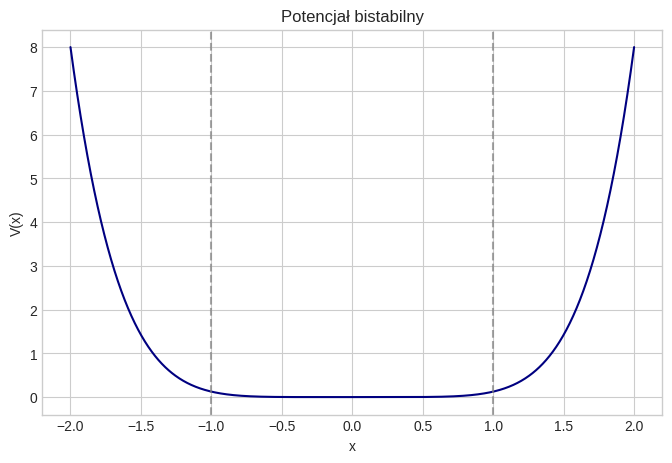

In [6]:
x_grid = np.linspace(-2, 2, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, - V(x_grid), color="navy")
plt.axvline(-1, ls="--", color="gray", alpha=0.7)
plt.axvline(1, ls="--", color="gray", alpha=0.7)
plt.title("Potencjał bistabilny")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.show()

Na powyższym wykresie widać potencjał bistabilny z dwoma minimami, odpowiadającymi dwóm stabilnym stanom układu. Przejścia cząstki pomiędzy tymi studniami są kluczowe dla wsytąpienia rezonansu stochastycznego.

In [7]:
def simulate_trajectory(D, A=A, omega_s=omega_s, dt=dt, N=N, x0=x0):
    x = np.zeros(N)
    x[0] = x0

    for n in range(N - 1):
        noise = np.sqrt(2 * D * dt) * np.random.randn()
        drift = force(x[n]) + A * np.sin(omega_s * t[n])
        x[n + 1] = x[n] +drift * dt + noise

    return x

In [8]:
D_values_demo = [0.02, 0.12, 0.35]
trajectories_demo = {}

for D in D_values_demo:
    trajectories_demo[D] = simulate_trajectory(D)

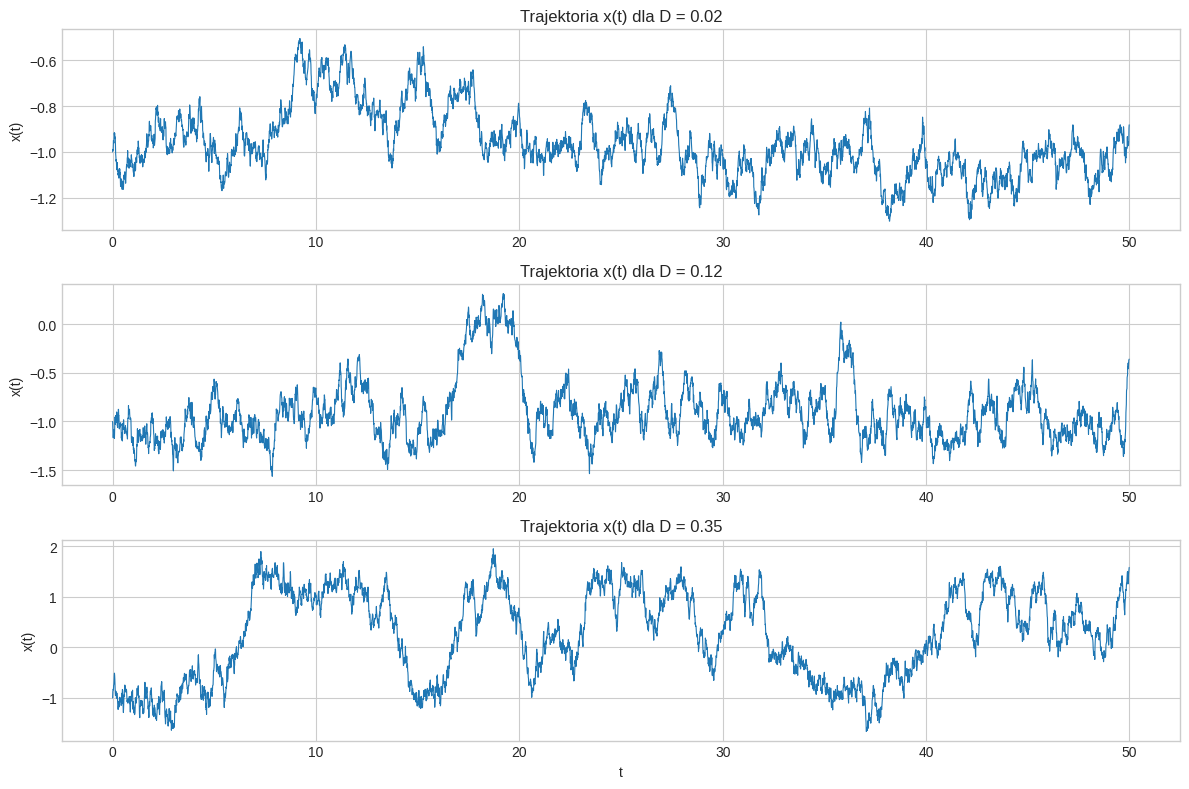

In [9]:
plt.figure(figsize=(12, 8))

time_window = 5000
time_axis = t[:time_window]

for i, D in enumerate(D_values_demo, 1):
    plt.subplot(len(D_values_demo), 1, i)
    plt.plot(time_axis, trajectories_demo[D][:time_window], lw=0.8)
    plt.title(f"Trajektoria x(t) dla D = {D}")
    plt.ylabel("x(t)")

plt.xlabel("t")
plt.tight_layout()
plt.show()

Dla bardzo małego szumu przejścia między studniami wystęują rzadko, ponieważ sygnał okresowy sam nie wystarcza do pokonania bariery potencjału. Dla pośrednich wartości D przejścia mogą zacząć synchronizować się z wymuszeniem. Natomiast dla zbyt dużego szumu ruch staje się zbyt chaotyczny i wpływ sygnału okresowego przestaje być wyraźny.

In [10]:
def power_spectrum(x, dt):
    x_centered = x - np.mean(x)
    fft_vals = np.fft.rfft(x_centered)
    freqs = np.fft.rfftfreq(len(x_centered), d=dt)
    psd = np.abs(fft_vals)**2 / len(x_centered)
    return freqs, psd

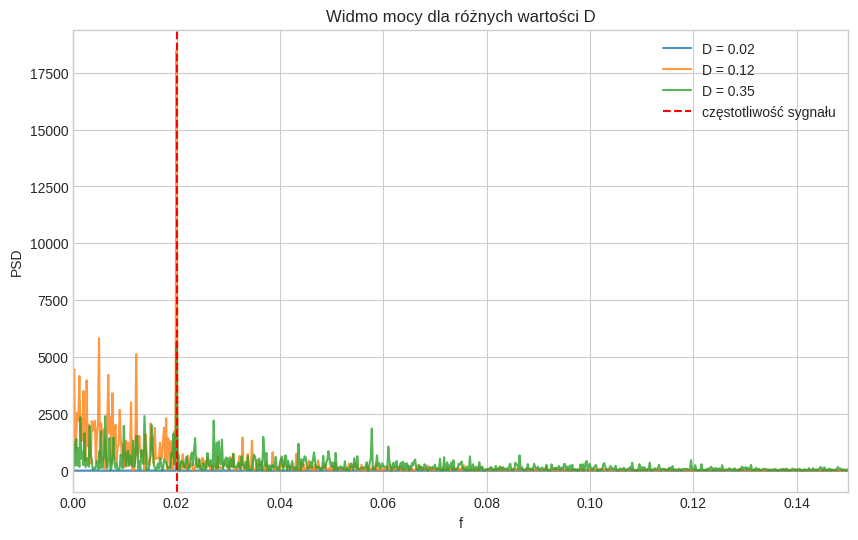

In [13]:
plt.figure(figsize=(10, 6))

for D in D_values_demo:
    x = trajectories_demo[D]
    freqs, psd = power_spectrum(x, dt)
    plt.plot(freqs, psd, label=f"D = {D}", alpha=0.8)

plt.xlim(0, 0.15)
plt.axvline(f_s, color="red", ls="--", label="częstotliwość sygnału")
plt.title("Widmo mocy dla różnych wartości D")
plt.xlabel("f")
plt.ylabel("PSD")
plt.legend()
plt.show()

Na wykresie widma mocy szczególne znaczenie ma pik w pobliżu częstotliwości wymuszenia $f_s$. Jego wysokość informuje o tym, jak silnie układ odpowiada na sygnał okresowy. Dla rezonansu stochastycznego oczekuje się, że odpowiedź ta będzie największa dla pewnej pośredniej wartości natężenia szumu.

## Potencjał zależny od czasu

W obecności wymuszenia okresowego potencjał efektywny układu zmienia się w czasie. Oznacz to, że wysokość bariery oddzielającej obie studnie nie jest stała, lecz moduluje się periodycznie wraz z sygnałem zewnętrznym.

To właśnie ta czasowa zmiana bariery powoduje, że prawdopodobieństwo przejścia cząstki z jednej studni do drugioej zmienia się asymetrycznie w czasie. Dla odpowiedniego poziomu szumu przejścia te mogą synchronizować się z wymuszeniem.

In [19]:
def V_eff(x, t, A=A, omega_s=omega_s):
    return -0.5 * x**2 + 0.25 * x**4 - A*x*np.sin(omega_s * t)

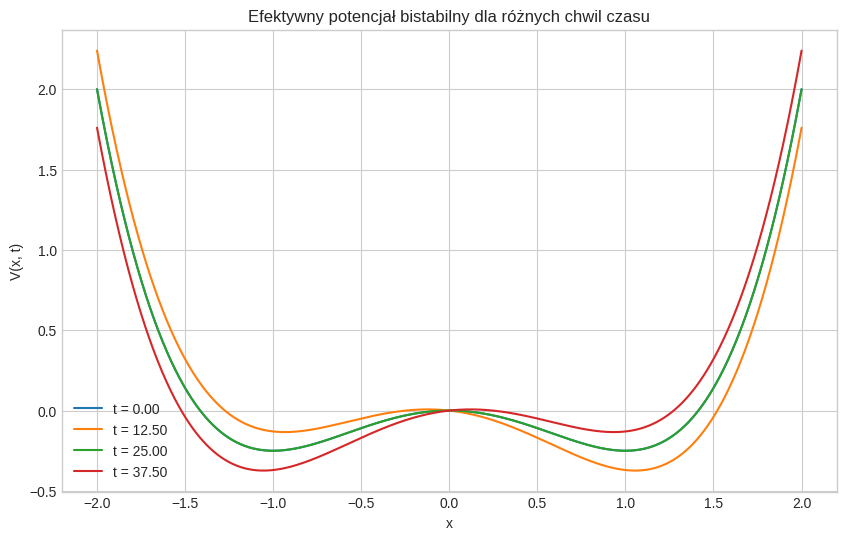

In [20]:
times_to_plot = [0,
                 0.25 * (2 * np.pi / omega_s),
                 0.5 * (2 * np.pi / omega_s),
                 0.75 * (2 * np.pi / omega_s)]

x_grid = np.linspace(-2, 2, 1000)

plt.figure(figsize=(10, 6))
for tau in times_to_plot:
    plt.plot(x_grid, V_eff(x_grid, tau), label=f"t = {tau:.2f}")

plt.title("Efektywny potencjał bistabilny dla różnych chwil czasu")
plt.xlabel("x")
plt.ylabel("V(x, t)")
plt.legend()
plt.show()

Na wykresie widać, że kształt potencjału zmienia się okresowo pod wpływem sygnału zewnętrznego. Jedna studnia staje się chwilowo bardziej uprzywilejowana energetycznie, a druga mniej, co prowadzi do periodycznej zmiany wysokości bariery dla przejść między stanami.

In [23]:
def local_extrema_barrier(t, A=A, omega_s=omega_s):
    x_dense = np.linspace(-2, 2, 4000)
    v = V_eff(x_dense, t, A=A, omega_s=omega_s)

    left_mask = x_dense < 0
    right_mask = x_dense > 0
    center_mask = np.abs(x_dense) < 0.5

    x_left = x_dense[left_mask][np.argmin(v[left_mask])]
    v_left = np.min(v[left_mask])

    x_right = x_dense[right_mask][np.argmin(v[right_mask])]
    v_right = np.min(v[right_mask])

    x_barrier = x_dense[center_mask][np.argmin(v[center_mask])]
    v_barrier = np.max(v[center_mask])

    delta_left = v_barrier - v_left
    delta_right = v_barrier - v_right

    return x_left, x_right, x_barrier, v_left, v_right, v_barrier, delta_left, delta_right

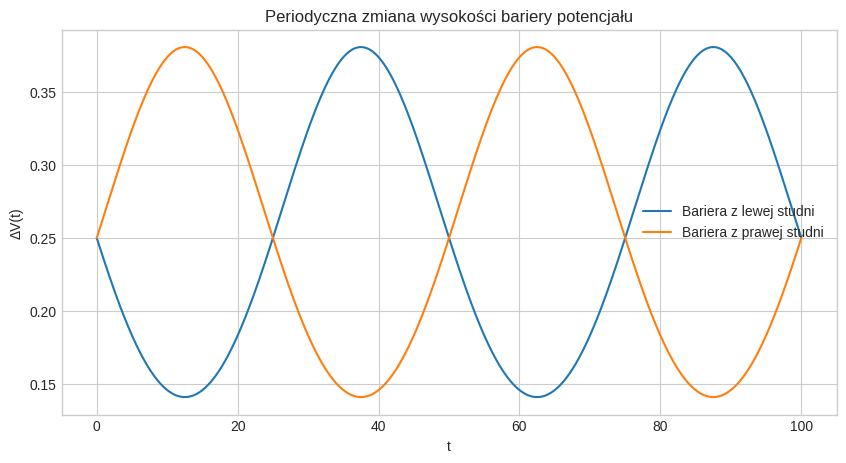

In [24]:
t_bar = np.linspace(0, 2 * (2 * np.pi / omega_s), 500)

delta_left_list = []
delta_right_list = []

for tt in t_bar:
    _, _, _, _, _, _, dL, dR = local_extrema_barrier(tt)
    delta_left_list.append(dL)
    delta_right_list.append(dR)

plt.figure(figsize=(10, 5))
plt.plot(t_bar, delta_left_list, label="Bariera z lewej studni")
plt.plot(t_bar, delta_right_list, label="Bariera z prawej studni")
plt.title("Periodyczna zmiana wysokości bariery potencjału")
plt.xlabel("t")
plt.ylabel("ΔV(t)")
plt.legend()
plt.show()

Wysokość bariery potencjału nie jest stała, lecz zmienia się okresowo w czasie. Oznacza to, że w różnych fazach wymuszenia zewnętrznego łatiwej jest opuśić lewą lub prawą studnię, co prowadzi do asymetrii przejść między stanami.

In [25]:
def kramers_rates(t, D, A=A, omega_s=omega_s):
    _, _, _, _, _, _, delta_left, delta_right = local_extrema_barrier(t, A=A, omega_s=omega_s)
    r_left_to_right = np.exp(-delta_left / D)
    r_right_to_left = np.exp(-delta_right / D)
    return r_left_to_right, r_right_to_left

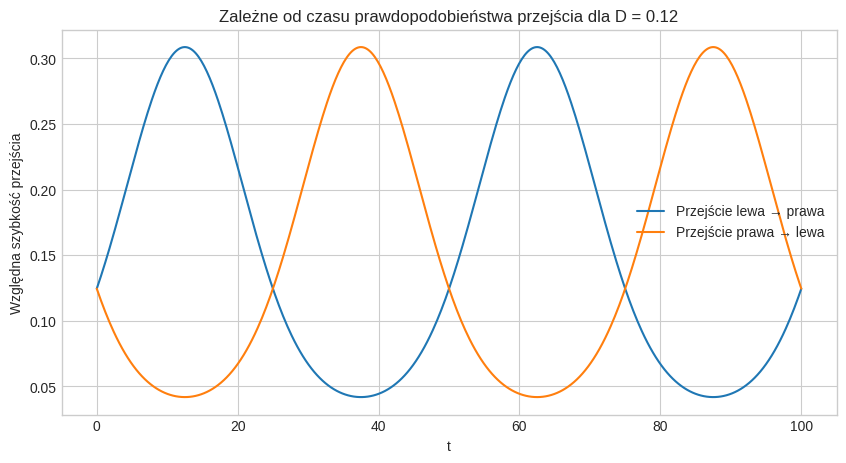

In [26]:
D_example = 0.12

rate_lr = []
rate_rl = []

for tt in t_bar:
    r1, r2 = kramers_rates(tt, D=D_example)
    rate_lr.append(r1)
    rate_rl.append(r2)

plt.figure(figsize=(10, 5))
plt.plot(t_bar, rate_lr, label="Przejście lewa → prawa")
plt.plot(t_bar, rate_rl, label="Przejście prawa → lewa")
plt.title(f"Zależne od czasu prawdopodobieństwa przejścia dla D = {D_example}")
plt.xlabel("t")
plt.ylabel("Względna szybkość przejścia")
plt.legend()
plt.show()

Ponieważ wysokość bariery zmienia się w czasie, zmienia się również prawdopodobieństwo przejścia między studniami. Gdy bariera dla jednej strony maleje, przejście z tej studni staje się bardziej prawdopodobne, co prowadzi do okresowej asymetrii dynamiki układu.

In [27]:
D_vis = 0.12
x_vis = simulate_trajectory(D_vis)

input_signal = A * np.sin(omega_s * t)
y_vis = np.where(x_vis >= 0, 1, -1)

window = 8000
tt = t[:window]

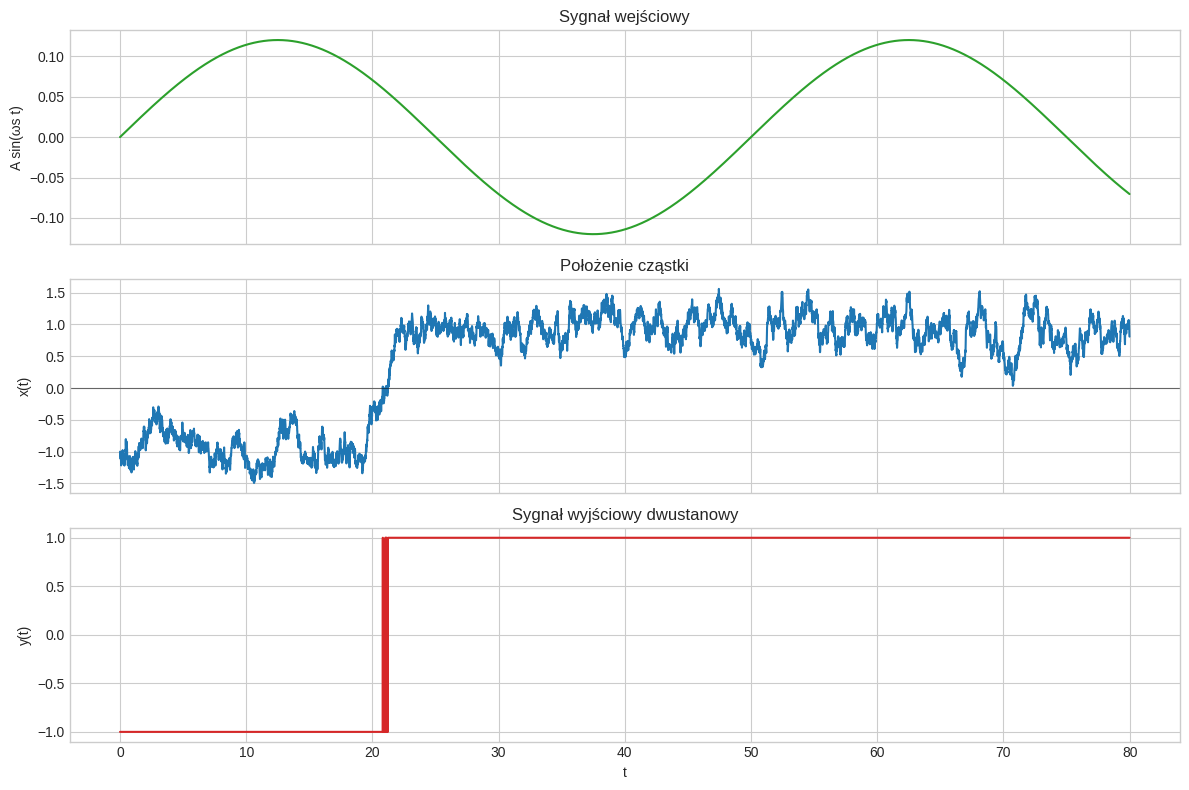

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(tt, input_signal[:window], color="tab:green")
axes[0].set_ylabel("A sin(ωs t)")
axes[0].set_title("Sygnał wejściowy")

axes[1].plot(tt, x_vis[:window], color="tab:blue")
axes[1].axhline(0, color="black", lw=0.8, alpha=0.5)
axes[1].set_ylabel("x(t)")
axes[1].set_title("Położenie cząstki")

axes[2].step(tt, y_vis[:window], where="post", color="tab:red")
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("t")
axes[2].set_title("Sygnał wyjściowy dwustanowy")

plt.tight_layout()
plt.show()

Na powyższych wykresach pokazano zależność między wymuzeniem okresowym a odpowiedzią ukłądu. Sygnał wyjściowy dwustanowy podkreśla momenty przejścia cząstki pomiędzy dwiema studniami potencjału i ułatwia ocenę synchronizcji z sygnałem wejściowym.

## Widmo mocy

Jedną z podstawowych metod charakteryzacji rezonansu stochastycznego jest analiza widma mocy sygnału wyjściowego. Szczególnie istotny jest pik przy częstotliwości wymuszenia, ponieważ jego obecność oznacza, że układ odpowiada na sygnał okresowy.

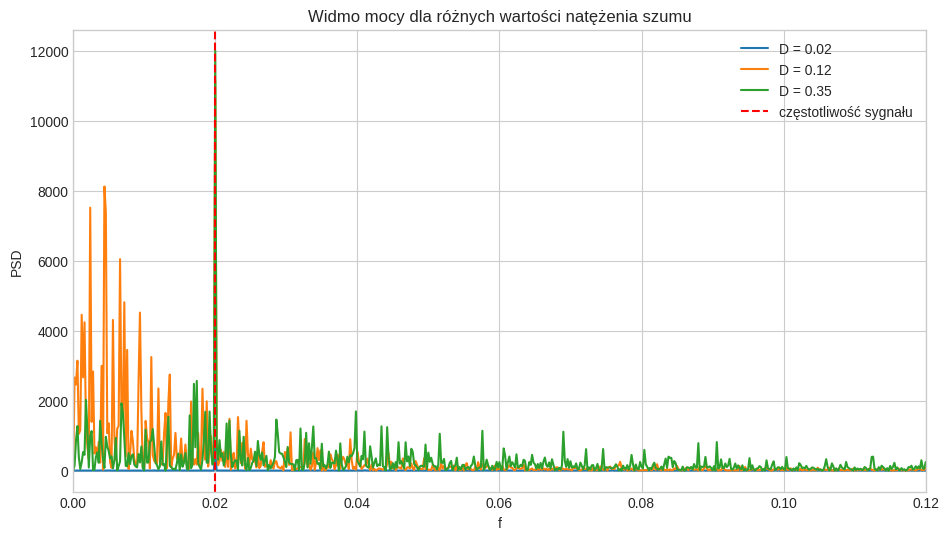

In [29]:
D_spectrum_values = [0.02, 0.12, 0.35]

plt.figure(figsize=(11, 6))

for D in D_spectrum_values:
    x_tmp = simulate_trajectory(D)
    freqs, psd = power_spectrum(x_tmp, dt)
    plt.plot(freqs, psd, label=f"D = {D}")

plt.axvline(f_s, color="red", linestyle="--", label="częstotliwość sygnału")
plt.xlim(0, 0.12)
plt.xlabel("f")
plt.ylabel("PSD")
plt.title("Widmo mocy dla różnych wartości natężenia szumu")
plt.legend()
plt.show()

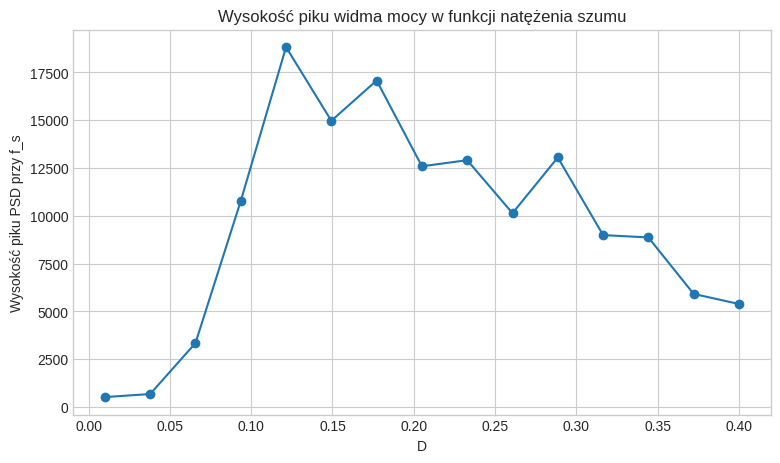

In [30]:
D_peak_scan = np.linspace(0.01, 0.4, 15)
peak_values = []

for D in D_peak_scan:
    x_tmp = simulate_trajectory(D)
    freqs, psd = power_spectrum(x_tmp, dt)
    idx = np.argmin(np.abs(freqs - f_s))
    peak_values.append(psd[idx])

plt.figure(figsize=(9, 5))
plt.plot(D_peak_scan, peak_values, marker="o")
plt.xlabel("D")
plt.ylabel("Wysokość piku PSD przy f_s")
plt.title("Wysokość piku widma mocy w funkcji natężenia szumu")
plt.show()

## Wnioski

W projekcie przedstawiono numeryczną analizę rezonansu stochastycznego w układzie bistabilnym pobudzanym sygnałem okresowym i szumem gaussowskim. Pokazano, że potencjał efektywny układu zmienia się periodycznie w czasie, co prowadzi do okresowej zmiany wysokości bariery między dwiema studniami.

Zmiana bariery wpływa na prawdopodobieństwo przejść między stanami, a odpowiedź układu można obserwować zarówno na przebeigach czasowych, jak i w widmie mocy. Szczególnie istotny jest pik przy częstotliwości wymuszenia, który potwierdza obecność składowej zsynchronizowanej z sygnałem zewnętrznym.

In [14]:
def estimate_snr(freqs, psd, f_signal, band=0.002):
    signal_idx = np.argmin(np.abs(freqs - f_signal))
    signal_power = psd[signal_idx]

    noise_mask = (freqs > f_signal - 5 * band) & (freqs < f_signal + 5 * band)
    noise_mask[signal_idx] = False

    noise_power = np.mean(psd[noise_mask])
    snr = signal_power / noise_power if noise_power > 0 else np.nan

    return snr, signal_power, noise_power

In [15]:
D_values = np.linspace(0.01, 0.5, 20)

snr_values = []
signal_values = []
noise_values = []

for D in D_values:
    x = simulate_trajectory(D)
    freqs, psd = power_spectrum(x, dt)
    snr, signal_power, noise_power = estimate_snr(freqs, psd, f_s)
    
    snr_values.append(snr)
    signal_values.append(signal_power)
    noise_values.append(noise_power)

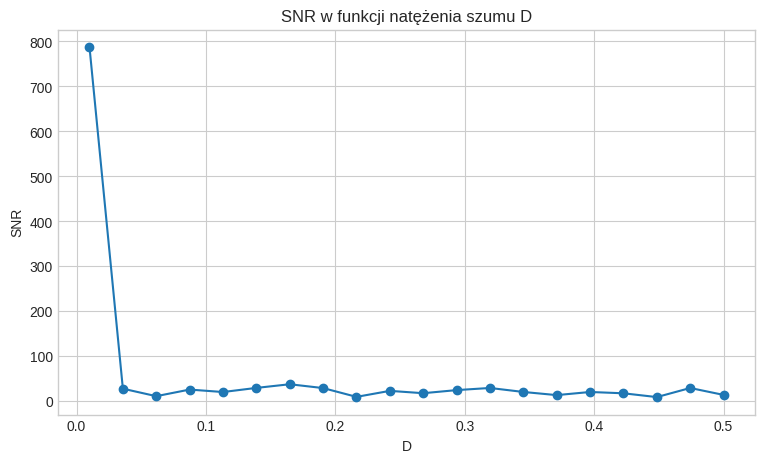

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(D_values, snr_values, marker="o")
plt.title("SNR w funkcji natężenia szumu D")
plt.xlabel("D")
plt.ylabel("SNR")
plt.show()

In [17]:
best_idx = np.nanargmax(snr_values)
best_D = D_values[best_idx]
best_SNR = snr_values[best_idx]

print("Najlepsza wartość D:", best_D)
print("Maksymalny SNR:", best_SNR)

Najlepsza wartość D: 0.01
Maksymalny SNR: 787.4180494107572


Wykres SNR w funkcji parametru D pokazuje istnienie maksimu dla pośredniej wartości natężenia szumu. Oznacza to, że szum o zbyt małej intensywności nie wspomaga przejść między studniami, natomiast zbyt duży szum niszczy regularność opdowiedzi. Najlepsza synchronizacja z sygnałem okresowym występuje dla pewnej optymalnej wartości D, co stanowi numeryczne potwierdzenie rezonansu stochastycznego.

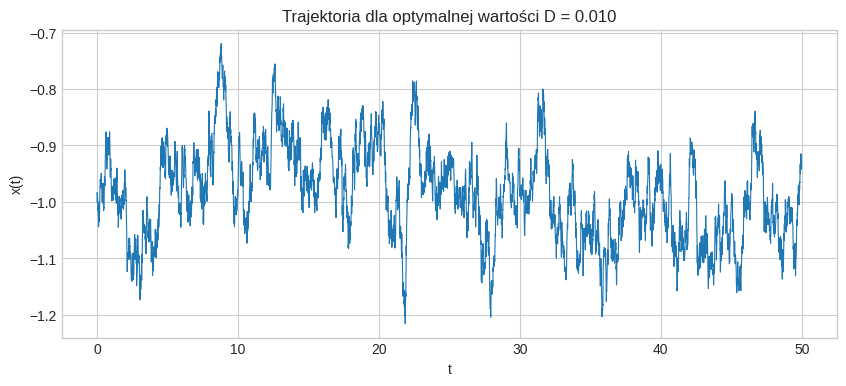

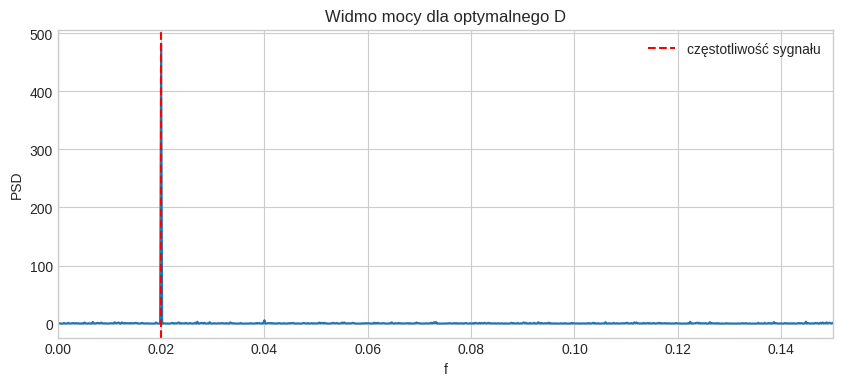

In [18]:
best_traj = simulate_trajectory(best_D)
freqs_best, psd_best = power_spectrum(best_traj, dt)

plt.figure(figsize=(10, 4))
plt.plot(t[:5000], best_traj[:5000], lw=0.8)
plt.title(f"Trajektoria dla optymalnej wartości D = {best_D:.3f}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(freqs_best, psd_best)
plt.axvline(f_s, color="red", ls="--", label="częstotliwość sygnału")
plt.xlim(0, 0.15)
plt.title("Widmo mocy dla optymalnego D")
plt.xlabel("f")
plt.ylabel("PSD")
plt.legend()
plt.show()

## Wnioski

W projekcie zasymulowano układ bistabilny pobudzany słabym sygnałem okresowym oraz szumem gaussowskim. Analiza trajektorii i widma mocy pokazała, że obecność szumu może wzmacniać odpowiedź układu na sygnał okresowy.

Najważniejszym wynikiem było otrzymanie maksimum współczynnika SNR dla pośredniej wartości natężenia szumu D. Oznacza to, że odpowiednio dobrany szum poprawia synchornizację przejść między studniami potencjału z wymuszeniem okresowym. Wynik ten jest zgodny z teorią rezonansu stochastycznego omawianą na wykładzie.